# Tutorial 4: Filter Duplicate Barcodes

## The Problem

A barcode should appear **once** per trace.
When it appears multiple times, it is a duplicate caused by:

- **Optical artifacts** — Same spot imaged twice (defocus, micro-movement)
- **Detector noise** — Spurious detections registered as separate spots
- **Identical Spot IDs** — Data duplication from processing pipeline

Tutorial 2 QC reveals duplicates in two plots:
- **Trace Statistics** → the N_repeated_barcodes histogram (right panel)
- **Barcode Repetition** → violins above 1.0 = barcodes appearing multiple times

## Available Methods

`trace_filter --clean_spots` handles duplicates in two steps:

1. **Remove duplicate Spot IDs** — identical rows in the trace table
2. **Resolve repeated barcodes** — same barcode appearing multiple times in one trace

For step 2, the behavior depends on whether a localization file is provided:

| Mode | Command | What happens to repeated barcodes |
|------|---------|-----------------------------------|
| **Trace only** | `--clean_spots` | All instances of repeated barcodes are **removed** |
| **With intensity** | `--clean_spots --localization_file Loc.dat` | The spot with the **highest peak intensity** is kept |

## Input

The merged trace file from Tutorial 1: `merged_traces.ecsv`

In [1]:
import matplotlib.pyplot as plt
import matplotlib.image as mpimg

data_path = "/home/xdevos/Repositories/pyHi-M/traceratops/data"
dest_path = f"{data_path}/output"

input_trace = f"{dest_path}/merged_traces.ecsv"

print(f"Input: {input_trace}")

Input: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces.ecsv


## Method 1: Trace-Only Mode (`--clean_spots`)

Without a localization file, `--clean_spots` takes a conservative approach:
- Duplicate Spot IDs (identical rows) are deduplicated
- For barcodes appearing more than once in a trace, **all instances are removed**

This is conservative: rather than guessing which spot is the "real" one, it removes all of them.
The trade-off is losing some data, but the remaining data is clean.

### Run the filter

In [2]:
!trace_filter --input {input_trace} --clean_spots -O cleaned

==========Started execution==========

$ trace files to process: ['/home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces.ecsv']

$ trace files to process= ['/home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces.ecsv']
$ Importing table from pyHiM format


Successfully loaded trace table: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces.ecsv



$ Removing duplicated barcodes within traces...



  0%|                                                | 0/115391 [00:00<?, ?it/s]


  1%|▏                                   | 755/115391 [00:00<00:15, 7544.75it/s]

...


 98%|███████████████████████████████▎| 108145/110358 [00:07<00:00, 14421.39it/s]


 99%|███████████████████████████████▊| 109643/110358 [00:07<00:00, 14583.66it/s]


100%|████████████████████████████████| 110358/110358 [00:07<00:00, 14521.79it/s]


$ Number of spots / traces left: 104863 / 20524
$ Saving output table as /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces_cleaned.ecsv ...


$ Saved output trace file at: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces_cleaned.ecsv
Processed <1> trace file(s)

=========Finished execution=========


### Compare before vs after

In [3]:
# Run QC on the cleaned file
cleaned_trace = f"{dest_path}/merged_traces_cleaned.ecsv"
!trace_analyzer --input {cleaned_trace}


1 trace files to process= /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces_cleaned.ecsv
$ Importing table from pyHiM format


Successfully loaded trace table: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces_cleaned.ecsv
> Analyzing traces for /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces_cleaned.ecsv
$ Number of spots in trace file: 104863


$ Calculating overall barcode detection across 20524 traces...


$ Exporting barcode detection plot to: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces_cleaned_barcode_detection.png


$ Saved neighbor distances plot: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces_cleaned_first_neighbor_distances.png
$ Mean distances between neighboring barcodes: X=-0.000, Y=-0.000, Z=0.002


...


 92%|████████████████████████████████▏  | 18886/20524 [00:02<00:00, 7656.29it/s]


 96%|█████████████████████████████████▌ | 19659/20524 [00:02<00:00, 7677.76it/s]


100%|███████████████████████████████████| 20524/20524 [00:02<00:00, 7454.57it/s]


$ Exporting relative barcode frequencies figure to: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces_cleaned_relative_barcode_frequencies.png


Finished execution


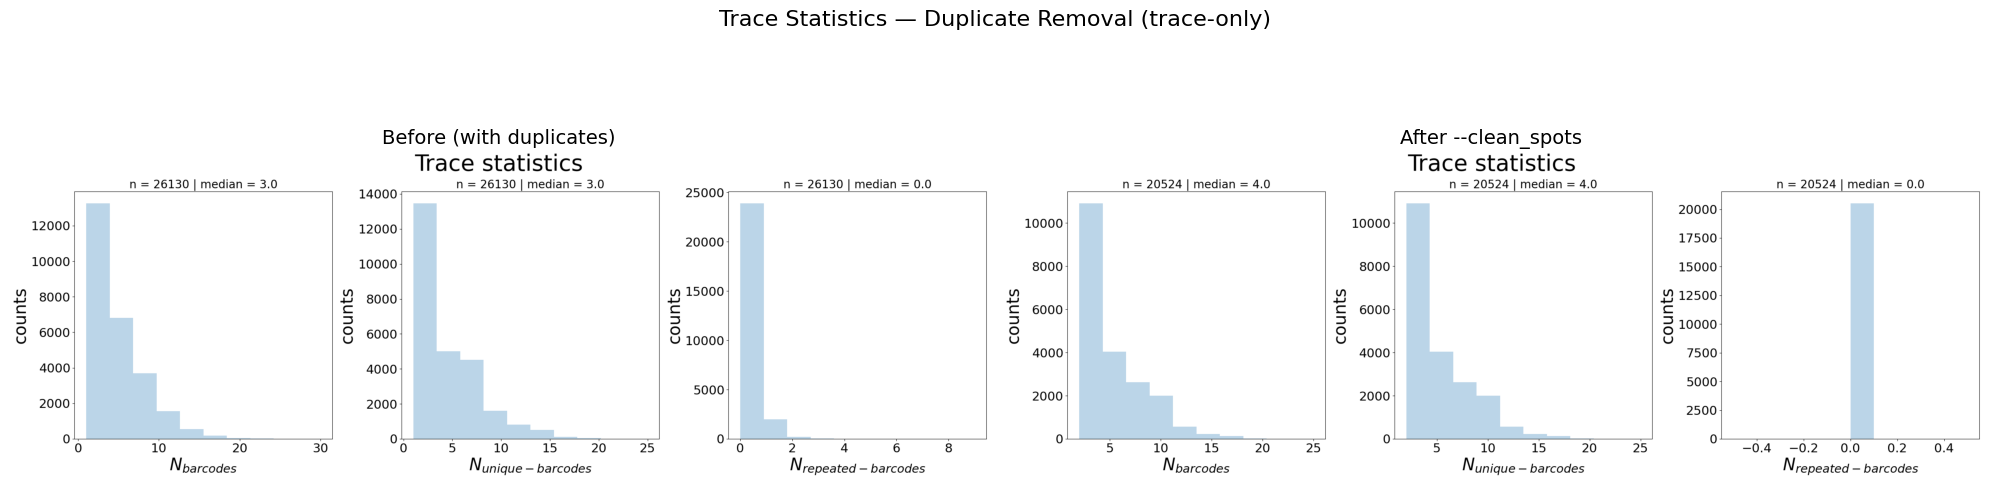

In [4]:
# Before vs after: Trace Statistics
before = f"{dest_path}/merged_traces_trace_statistics.png"
after = f"{dest_path}/merged_traces_cleaned_trace_statistics.png"

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
for ax, f, title in zip(axes, [before, after],
                         ["Before (with duplicates)", "After --clean_spots"]):
    ax.imshow(mpimg.imread(f))
    ax.set_title(title, fontsize=14)
    ax.axis('off')
fig.suptitle("Trace Statistics — Duplicate Removal (trace-only)", fontsize=16)
plt.tight_layout()
plt.show()

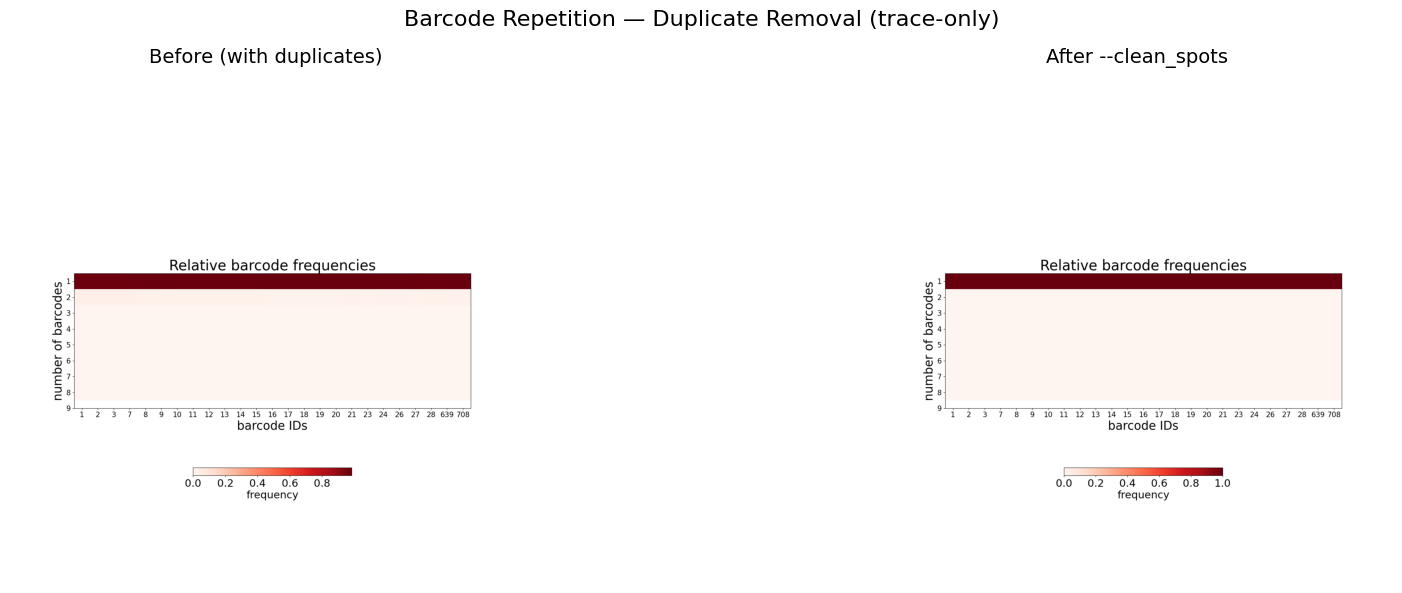

In [5]:
# Before vs after: Barcode Repetition Frequencies
before = f"{dest_path}/merged_traces_relative_barcode_frequencies.png"
after = f"{dest_path}/merged_traces_cleaned_relative_barcode_frequencies.png"

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
for ax, f, title in zip(axes, [before, after],
                         ["Before (with duplicates)", "After --clean_spots"]):
    ax.imshow(mpimg.imread(f))
    ax.set_title(title, fontsize=14)
    ax.axis('off')
fig.suptitle("Barcode Repetition — Duplicate Removal (trace-only)", fontsize=16)
plt.tight_layout()
plt.show()

**What to check:**
- The N_repeated_barcodes histogram (right panel of Trace Statistics) should drop to near zero
- The Barcode Repetition violins should collapse toward 1.0 (each barcode appears once per trace)

> **Limitation**: In trace-only mode, repeated barcodes are entirely removed (both the real and artifact spots). This means some real detections are lost. Method 2 avoids this by using intensity to choose the best spot.

## Method 2: Intensity-Based Resolution (`--clean_spots --localization_file`)

When a localization file is available, `trace_filter` can resolve duplicates more intelligently:
for each repeated barcode in a trace, it keeps the spot with the **highest peak intensity** and removes the others.

This preserves more data because the best detection is kept instead of discarding all duplicates.

### Step 1: Collect localization files

Localization files are per-ROI (one per imaging region). We need to collect and merge them,
just like we did for trace files in Tutorial 1.

In [6]:
# Collect localization files from all ROIs
!collect_files \
    --root {data_path}/RUT \
    --example-file "localizations_3D_barcode.dat" \
    --copy-to {dest_path}/raw_localizations \
    --rename \
    --force

Matched (13):
  013_ROI -> /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/013_ROI/localize_3d/data/localizations_3D_barcode.dat
  014_ROI -> /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/014_ROI/localize_3d/data/localizations_3D_barcode.dat
  015_ROI -> /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/015_ROI/localize_3d/data/localizations_3D_barcode.dat
  017_ROI -> /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/017_ROI/localize_3d/data/localizations_3D_barcode.dat
  018_ROI -> /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/018_ROI/localize_3d/data/localizations_3D_barcode.dat
  019_ROI -> /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/019_ROI/localize_3d/data/localizations_3D_barcode.dat
  020_ROI -> /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/020_ROI/localize_3d/data/localizations_3D_barcode.dat
  021_ROI -> /home/xdevos/Repositories/pyHi-M/traceratops/data/RUT/021_ROI/localize_3d/data/localizations_3D_barcode.dat
  022_ROI -> /home


Copied 13 file(s) to /home/xdevos/Repositories/pyHi-M/traceratops/data/output/raw_localizations


In [7]:
# Merge all localization files into one
!ls {dest_path}/raw_localizations/*.dat | localization_merge -O {dest_path} -o merged_localizations.dat

Input parameters
---------------
outputFolder-->/home/xdevos/Repositories/pyHi-M/traceratops/data/output
output_file-->merged_localizations.dat
loc_files-->['/home/xdevos/Repositories/pyHi-M/traceratops/data/output/raw_localizations/localizations_3D_barcode_013_ROI.dat', '/home/xdevos/Repositories/pyHi-M/traceratops/data/output/raw_localizations/localizations_3D_barcode_014_ROI.dat', '/home/xdevos/Repositories/pyHi-M/traceratops/data/output/raw_localizations/localizations_3D_barcode_015_ROI.dat', '/home/xdevos/Repositories/pyHi-M/traceratops/data/output/raw_localizations/localizations_3D_barcode_017_ROI.dat', '/home/xdevos/Repositories/pyHi-M/traceratops/data/output/raw_localizations/localizations_3D_barcode_018_ROI.dat', '/home/xdevos/Repositories/pyHi-M/traceratops/data/output/raw_localizations/localizations_3D_barcode_019_ROI.dat', '/home/xdevos/Repositories/pyHi-M/traceratops/data/output/raw_localizations/localizations_3D_barcode_020_ROI.dat', '/home/xdevos/Repositories/pyHi-M/trac

$ Successfully loaded barcode localizations file: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/raw_localizations/localizations_3D_barcode_013_ROI.dat
$ Number of barcodes read from barcode_map: 25
$ Unique Barcodes detected: [  1   2   3   7   8   9  10  11  12  13  14  15  16  17  18  19  20  21
  23  24  26  27  28 639 708]
 $ appended loc file with 20146 localizations
$ loc file to process: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/raw_localizations/localizations_3D_barcode_014_ROI.dat
$ Importing table from pyHiM format


$ Successfully loaded barcode localizations file: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/raw_localizations/localizations_3D_barcode_014_ROI.dat
$ Number of barcodes read from barcode_map: 25
$ Unique Barcodes detected: [  1   2   3   7   8   9  10  11  12  13  14  15  16  17  18  19  20  21
  23  24  26  27  28 639 708]
 $ appended loc file with 21573 localizations
$ loc file to process: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/raw_localizations/localizations_3D_barcode_015_ROI.dat
$ Importing table from pyHiM format


$ Successfully loaded barcode localizations file: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/raw_localizations/localizations_3D_barcode_015_ROI.dat
$ Number of barcodes read from barcode_map: 24
$ Unique Barcodes detected: [  1   2   3   7   8   9  10  11  12  13  14  15  16  17  18  19  20  23
  24  26  27  28 639 708]
 $ appended loc file with 12773 localizations
$ loc file to process: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/raw_localizations/localizations_3D_barcode_017_ROI.dat
$ Importing table from pyHiM format


$ Successfully loaded barcode localizations file: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/raw_localizations/localizations_3D_barcode_017_ROI.dat
$ Number of barcodes read from barcode_map: 25
$ Unique Barcodes detected: [  1   2   3   7   8   9  10  11  12  13  14  15  16  17  18  19  20  21
  23  24  26  27  28 639 708]
 $ appended loc file with 19639 localizations
$ loc file to process: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/raw_localizations/localizations_3D_barcode_018_ROI.dat
$ Importing table from pyHiM format


...

 $ appended loc file with 14005 localizations
$ loc file to process: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/raw_localizations/localizations_3D_barcode_024_ROI.dat
$ Importing table from pyHiM format


$ Successfully loaded barcode localizations file: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/raw_localizations/localizations_3D_barcode_024_ROI.dat
$ Number of barcodes read from barcode_map: 25
$ Unique Barcodes detected: [  1   2   3   7   8   9  10  11  12  13  14  15  16  17  18  19  20  21
  23  24  26  27  28 639 708]
 $ appended loc file with 8103 localizations
$ loc file to process: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/raw_localizations/localizations_3D_barcode_025_ROI.dat
$ Importing table from pyHiM format


$ Successfully loaded barcode localizations file: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/raw_localizations/localizations_3D_barcode_025_ROI.dat
$ Number of barcodes read from barcode_map: 25
$ Unique Barcodes detected: [  1   2   3   7   8   9  10  11  12  13  14  15  16  17  18  19  20  21
  23  24  26  27  28 639 708]
 $ appended loc file with 20982 localizations
$ loc file to process: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/raw_localizations/localizations_3D_barcode_026_ROI.dat
$ Importing table from pyHiM format


$ Successfully loaded barcode localizations file: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/raw_localizations/localizations_3D_barcode_026_ROI.dat
$ Number of barcodes read from barcode_map: 25
$ Unique Barcodes detected: [  1   2   3   7   8   9  10  11  12  13  14  15  16  17  18  19  20  21
  23  24  26  27  28 639 708]
 $ appended loc file with 14593 localizations
 $ Merged loc file will contain 211922 localizations
Read and accumulated 13 localization files
$ Saving output table as /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_localizations.dat ...


$ Saved merged file to: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_localizations.dat
Finished execution


### Step 2: Run `--clean_spots` with the localization file

By providing `--localization_file`, the duplicate resolution changes:
instead of removing all instances of a repeated barcode, it looks up each spot's **peak intensity**
in the localization table and keeps the brightest one.

In [8]:
loc_file = f"{dest_path}/merged_localizations.dat"

!trace_filter --input {input_trace} --clean_spots --localization_file {loc_file} -O cleaned_intensity

==========Started execution==========

$ trace files to process: ['/home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces.ecsv']

$ trace files to process= ['/home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces.ecsv']
$ Importing table from pyHiM format


$ Successfully loaded barcode localizations file: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_localizations.dat
$ Number of barcodes read from barcode_map: 25
$ Unique Barcodes detected: [  1   2   3   7   8   9  10  11  12  13  14  15  16  17  18  19  20  21
  23  24  26  27  28 639 708]
$ Loaded localizations table with: 211922 rows
$ Importing table from pyHiM format


Successfully loaded trace table: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces.ecsv

$ Removing duplicated barcodes within traces...


$ Using intensity to resolve duplicates...



  0%|                                                 | 0/26130 [00:00<?, ?it/s]

...


 97%|███████████████████████████████ | 109518/112851 [00:07<00:00, 14884.33it/s]


 98%|███████████████████████████████▍| 111019/112851 [00:07<00:00, 14918.86it/s]


100%|████████████████████████████████| 112851/112851 [00:07<00:00, 14901.49it/s]


$ Number of spots / traces left: 107403 / 20682
$ Saving output table as /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces_cleaned_intensity.ecsv ...


$ Saved output trace file at: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces_cleaned_intensity.ecsv
Processed <1> trace file(s)

=========Finished execution=========


### Step 3: Compare the two methods

In [9]:
# Run QC on the intensity-cleaned file
intensity_cleaned = f"{dest_path}/merged_traces_cleaned_intensity.ecsv"
!trace_analyzer --input {intensity_cleaned}


1 trace files to process= /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces_cleaned_intensity.ecsv
$ Importing table from pyHiM format


Successfully loaded trace table: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces_cleaned_intensity.ecsv
> Analyzing traces for /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces_cleaned_intensity.ecsv
$ Number of spots in trace file: 107403


$ Calculating overall barcode detection across 20682 traces...


$ Exporting barcode detection plot to: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces_cleaned_intensity_barcode_detection.png


$ Saved neighbor distances plot: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces_cleaned_intensity_first_neighbor_distances.png
$ Mean distances between neighboring barcodes: X=-0.000, Y=-0.000, Z=0.002


...


 95%|█████████████████████████████████▎ | 19719/20682 [00:02<00:00, 7412.93it/s]


 99%|██████████████████████████████████▋| 20474/20682 [00:02<00:00, 7452.26it/s]


100%|███████████████████████████████████| 20682/20682 [00:02<00:00, 7214.00it/s]


$ Exporting relative barcode frequencies figure to: /home/xdevos/Repositories/pyHi-M/traceratops/data/output/merged_traces_cleaned_intensity_relative_barcode_frequencies.png


Finished execution


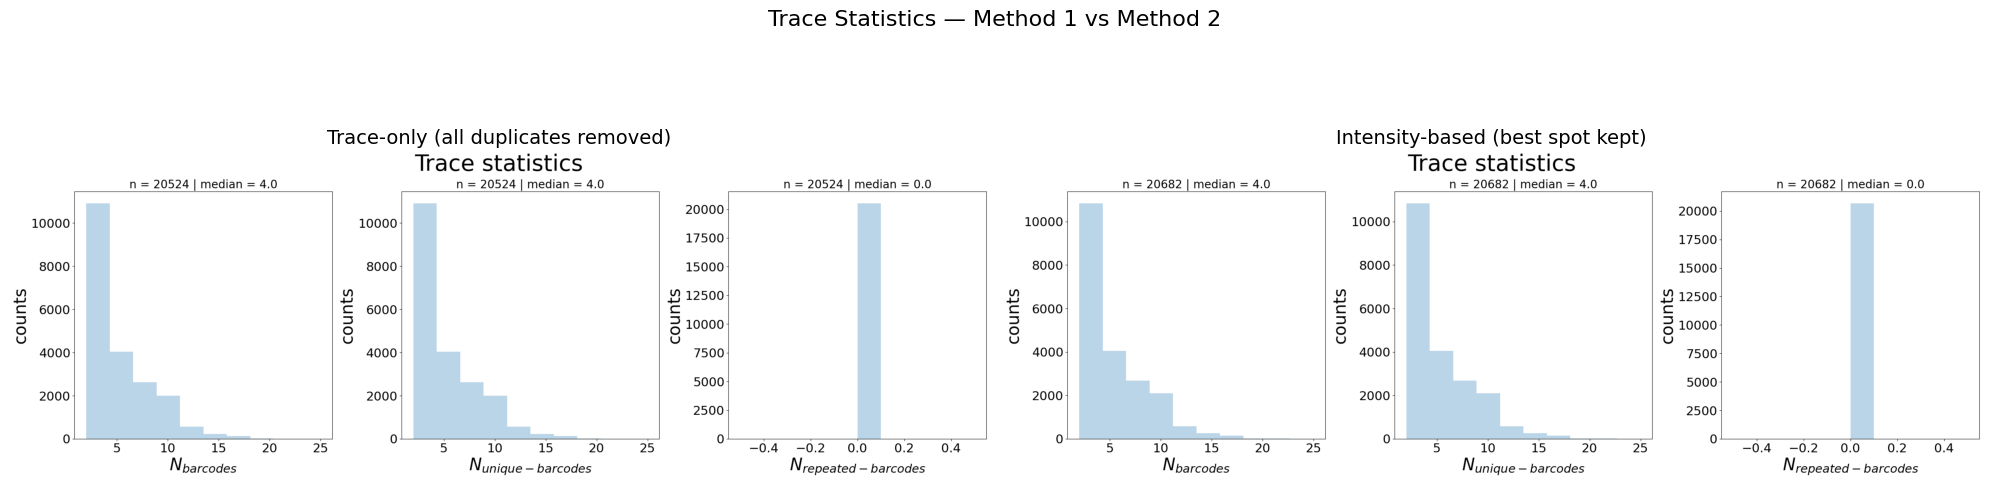

In [10]:
# Compare: trace-only vs intensity-based
trace_only = f"{dest_path}/merged_traces_cleaned_trace_statistics.png"
intensity = f"{dest_path}/merged_traces_cleaned_intensity_trace_statistics.png"

fig, axes = plt.subplots(1, 2, figsize=(20, 6))
for ax, f, title in zip(axes, [trace_only, intensity],
                         ["Trace-only (all duplicates removed)",
                          "Intensity-based (best spot kept)"]):
    ax.imshow(mpimg.imread(f))
    ax.set_title(title, fontsize=14)
    ax.axis('off')
fig.suptitle("Trace Statistics — Method 1 vs Method 2", fontsize=16)
plt.tight_layout()
plt.show()

**Expected difference:**
- Method 2 (intensity) preserves more spots because the best duplicate is kept
- The N_barcodes distribution should be shifted right (more barcodes per trace) compared to Method 1
- Both methods should show N_repeated_barcodes near zero

## Combining with Other Filters

Duplicate cleaning is typically combined with other filters in a single command:

```bash
# Trace-only approach
trace_filter --input merged_traces.ecsv \
    --clean_spots \
    --n_barcodes 4 \
    -O final

# With localization intensity
trace_filter --input merged_traces.ecsv \
    --clean_spots \
    --localization_file merged_localizations.dat \
    --n_barcodes 4 \
    -O final
```

**Filter order** inside `trace_filter`:
1. Duplicate/repeated barcode cleaning (`--clean_spots`) ← runs first
2. Coordinate filtering (`--z_min`, etc.)
3. Barcode removal (`--remove_barcode`)
4. Label filtering (`--keep_label` / `--remove_label`)
5. Barcode count (`--n_barcodes`) ← runs last (after other filters reduced trace length)

## Summary

| Method | Command | Behavior | Data preserved |
|--------|---------|----------|----------------|
| Trace-only | `--clean_spots` | Removes all instances of repeated barcodes | Less (conservative) |
| With intensity | `--clean_spots --localization_file` | Keeps highest-peak spot | More (best spot kept) |

**Which to choose?**
- **Trace-only**: Quick, no extra files needed, but removes some real detections
- **With intensity**: Requires localization files but preserves more data. Recommended when localization files are available.

**Next:** [Tutorial 5 — Split Oversized Traces](tutorial_05_split_traces.ipynb)